# ___Transformations to Images and Annotations___
----------------------------------

In [1]:
!python --version

Python 3.13.9


The system cannot find the path specified.


In [87]:
import json
import os
from PIL import Image
from typing import Optional

import torch
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(2025 - 12 - 4)
import pycocotools.mask as mask # https://github.com/tensorflow/datasets/blob/master/tensorflow_datasets/core/lazy_imports_lib.py
# this is how TF imports pycocotools

from numpy.typing import NDArray
from matplotlib.axes import Axes

In [3]:
# we'll need an image and example annotation
os.listdir(r"./sa1b/") # a few images and annotations from the SA-1B dataset from Meta

['sa_5857.jpg',
 'sa_5857.json',
 'sa_5906.jpg',
 'sa_5906.json',
 'sa_9480.jpg',
 'sa_9480.json']

In [4]:
images = {fname.replace(".jpg", ''): Image.open(f"./sa1b/{fname}") for fname in os.listdir(r"./sa1b/") if fname.endswith(r".jpg")}
annotations = dict.fromkeys(images.keys())
for fname in os.listdir(r"./sa1b/"):
    if fname.endswith(r".json"):
        with open(f"./sa1b/{fname}", mode="r") as fp:
            annotations[fname.replace(".json", '')] = json.load(fp=fp)

In [5]:
images

{'sa_5857': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2250x1500>,
 'sa_5906': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2098x1500>,
 'sa_9480': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2250x1500>}

In [6]:
len(annotations), annotations.keys() # good :)

(3, dict_keys(['sa_5857', 'sa_5906', 'sa_9480']))

In [26]:
# SA-1B uses COCO RLE format for encoding segmentations
# to decode the variable RLE encoding => use https://github.com/cocodataset/cocoapi/tree/master/PythonAPI aka pycocotools, which requires VS BuildTools to be installed on the machine

annotations["sa_5857"]["annotations"][0]

{'bbox': [540.0, 1029.0, 75.0, 24.0],
 'area': 1497,
 'segmentation': {'size': [1500, 2250],
  'counts': 'mPhh05d^15M3M2N101N2O001O001O0O1000001O0000001O000000001O0000000000000000000000O1000000000000O10000O2O000O1000000O1000000O1000000O10001O0O10000O2O0O100O2N2N2M_ahZ2'},
 'predicted_iou': 0.9336011409759521,
 'point_coords': [[546.1875, 1039.3125]],
 'crop_box': [499.0, 933.0, 755.0, 567.0],
 'id': 342774314,
 'stability_score': 0.9808707237243652}

In [24]:
annotations["sa_5857"]["annotations"][0]["segmentation"]

{'size': [1500, 2250],
 'counts': 'mPhh05d^15M3M2N101N2O001O001O0O1000001O0000001O000000001O0000000000000000000000O1000000000000O10000O2O000O1000000O1000000O1000000O10001O0O10000O2O0O100O2N2N2M_ahZ2'}

In [22]:
annotations["sa_5857"]["annotations"][0]["segmentation"]["size"] # [h, w]

[1500, 2250]

In [41]:
# following the pointers provided here => https://www.tensorflow.org/datasets/catalog/segment_anything
# DO NOT USE THE frPyObjects() FOLLOWED BY decode() APROACH HERE (from pycocotools.coco import maskUtils), THAT PERHAPS ONLY WORKS WHEN THE COUNTS IS AN ARRAY OF INTERES NOT STRINGS???
# mask.decode expects a dict in the following format
# {'size': [h, w], 'counts': counts}

_mask = mask.decode(annotations["sa_5857"]["annotations"][0]["segmentation"])

In [42]:
sa_5857_masks = np.array([mask.decode(_["segmentation"]) for _ in annotations["sa_5857"]["annotations"]])

In [45]:
sa_5857_masks.shape # 88 masks :)
# let's plot them

(88, 1500, 2250)

In [62]:
# got the inspiration from the show_anns function from https://github.com/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb
# the trick to overlay the mask without shadowing the image is to turn the binary single channel mask into a 4 channel mask (RGBA)
rgbalpha = np.ones(shape=(1500, 2250, 4))
rgbalpha[:, :, 3] = 0 # set the alpha channel to 0

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(1500, 2250))

In [73]:
np.concatenate([np.random.random(3), [0.35]]) # this is going to be the colour for the mask with an alpha of 0.35
mask_color = np.array([*np.random.random(3), 0.35])
mask_color

array([0.10662679, 0.10907117, 0.15400809, 0.35      ])

In [81]:
sa_5857_masks[0].sum() # cool :)

np.uint64(1497)

In [82]:
rgbalpha[sa_5857_masks[0].astype(np.bool), :] = mask_color # update the colour of the pixels included in the mask
rgbalpha

array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       ...,

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1.

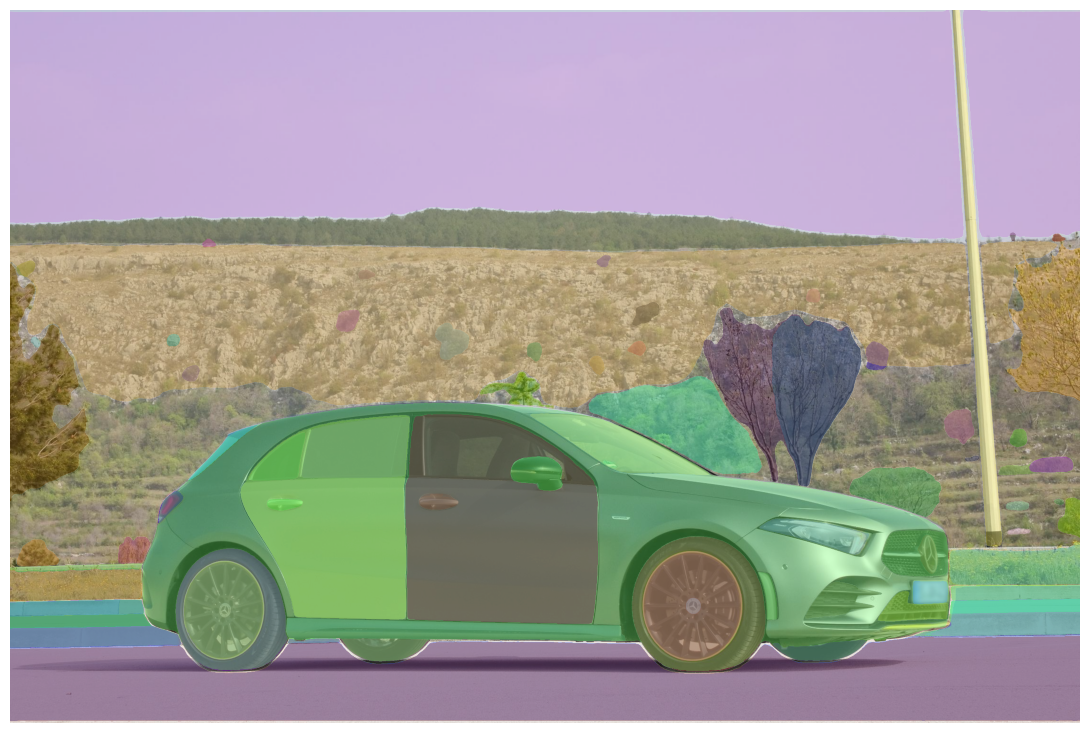

In [86]:
fig, axes = plt.subplots()
fig.set_size_inches(11, 7.5)
axes.set_axis_off()
axes.imshow(images["sa_5857"])
rgba = np.ones(shape=(1500, 2250, 4))

for m in sa_5857_masks:
    rgba[:, :, 3] = 0
    rgba[m.astype(np.bool), :] = np.array([*np.random.random(3), 0.35])
    axes.imshow(rgba)
plt.tight_layout()
plt.show() # tada :)

In [110]:
def plot_annotations(ax: Axes, masks: NDArray[np.integer], height: int, width: int, alpha: float=0.35) -> Axes:
    """
    """

    rgba = np.ones((height, width, 4))
    for mask in masks:
        rgba[:, :, 3] = 0 # set all the alpha channel values to 0
        # use the boolean mask to cherry pick the elements where the mask applies
        rgba[mask.astype(np.bool), :] = np.array([*np.random.random(3), alpha]) # and update the colour (RGB) values with the specified alpha value
        ax.imshow(rgba)
    return ax

In [109]:
sa_9480 = np.array(images["sa_9480"])
sa_9480_masks = np.array([mask.decode(_["segmentation"]) for _ in annotations["sa_9480"]["annotations"]])

In [111]:
sa_9480_masks.shape # 94 masks

(94, 1500, 2250)

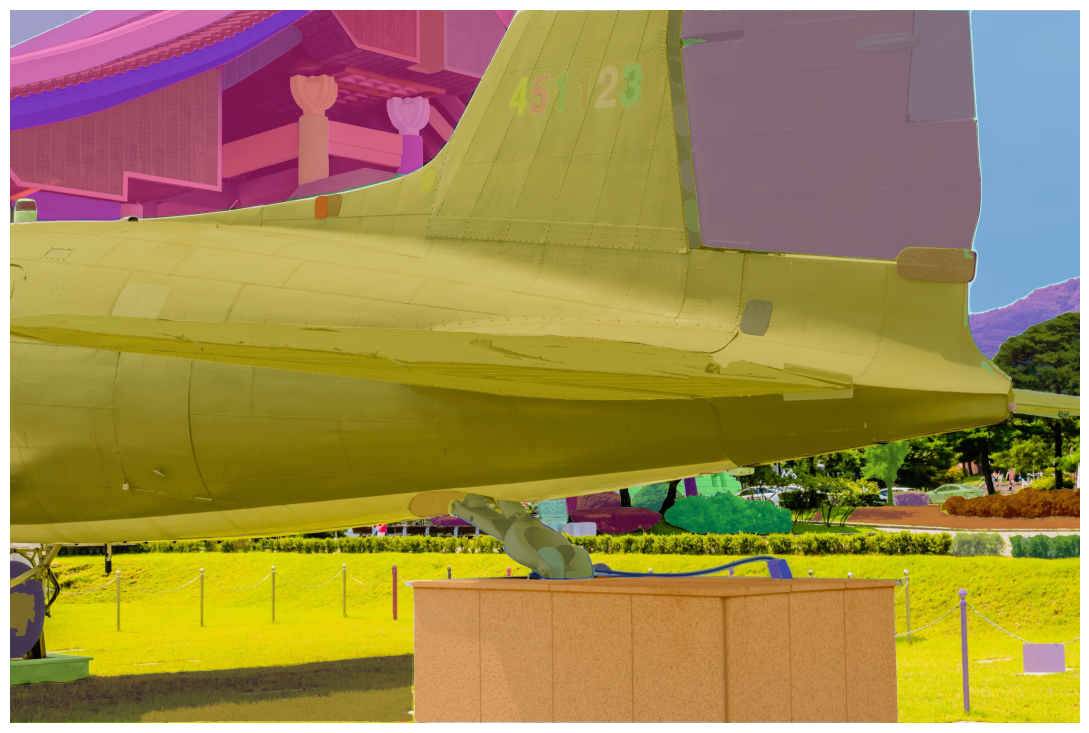

In [113]:
fig, axes = plt.subplots()
fig.set_size_inches(11, 7.5)
axes.set_axis_off()
axes.imshow(sa_9480)
plot_annotations(ax=axes, masks=sa_9480_masks, height=1500, width=2250, alpha=0.5)
plt.tight_layout()
plt.show()

In [119]:
sa_5906 = np.array(images["sa_5906"])
sa_5906_masks = np.array([mask.decode(_["segmentation"]) for _ in annotations["sa_5906"]["annotations"]])

In [120]:
sa_5906.shape

(1500, 2098, 3)

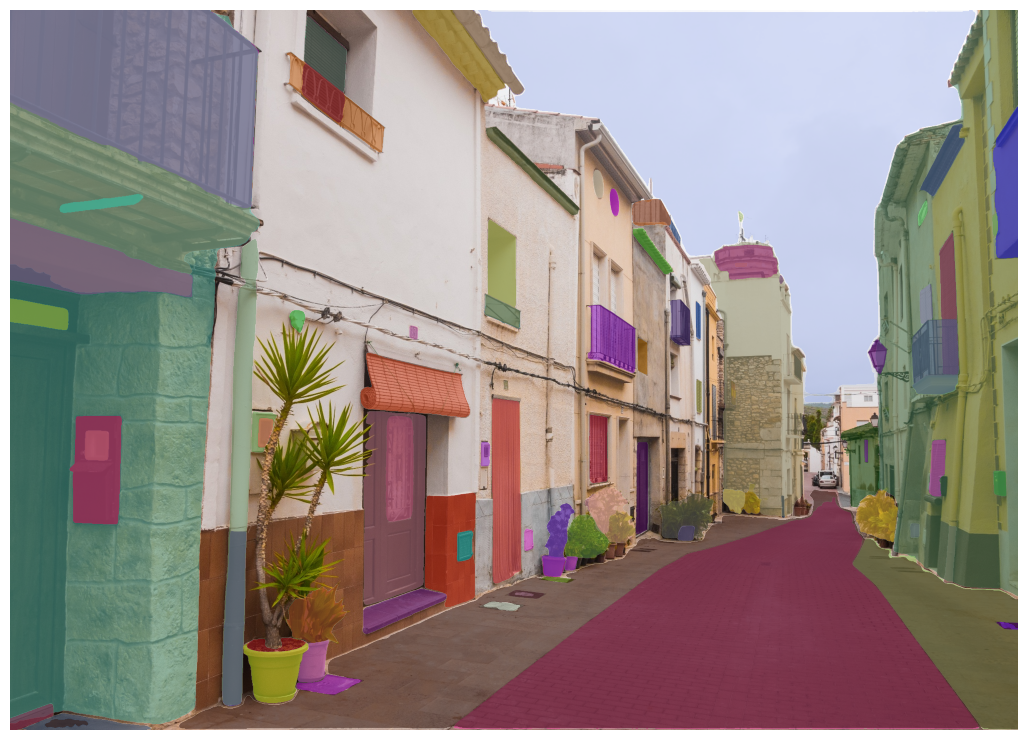

In [121]:
fig, axes = plt.subplots()
fig.set_size_inches(11, 7.5)
axes.set_axis_off()
axes.imshow(sa_5906)
plot_annotations(ax=axes, masks=sa_5906_masks, height=1500, width=2098, alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Now it's the time for transformations of images and masks